# Image Colorization ML Pipeline using Transfer Learning (U-Net + ResNet Backbone)
This notebook implements an end-to-end deep learning pipeline to colorize black and white landscape images.
It maps the Grayscale ($L$ channel) to the Chrominance ($a, b$ channels) using the Lab Color Space.

## Cell 2: Code (Dependencies & Device Setup)

In [1]:
!pip install torch torchvision scikit-image matplotlib pillow tqdm kagglehub

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from skimage.color import rgb2lab, lab2rgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.5 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

## Cell 3: Code (Dataset Download & Path Exploration)

In [2]:
import kagglehub

# 1. Download the latest version of the landscape dataset
path = kagglehub.dataset_download("arnaud58/landscape-pictures")
print("Path to dataset files:", path)

# 2. Extract all image paths recursively across subfolders
image_paths = glob.glob(os.path.join(path, "**/*.jpg"), recursive=True) + \
              glob.glob(os.path.join(path, "**/*.jpeg"), recursive=True)

print(f"Total landscape images discovered: {len(image_paths)}")

# Split into Train and Validation sets (90% / 10%)
split_idx = int(len(image_paths) * 0.9)
train_paths = image_paths[:split_idx]
val_paths = image_paths[split_idx:]

print(f"Training samples: {len(train_paths)} | Validation samples: {len(val_paths)}")

Path to dataset files: /kaggle/input/datasets/arnaud58/landscape-pictures
Total landscape images discovered: 4319
Training samples: 3887 | Validation samples: 432


## Cell 4: Code (Custom PyTorch Dataset)

In [3]:
class LandscapeColorizationDataset(Dataset):
    def __init__(self, paths, img_size=256):
        self.paths = paths
        self.img_size = img_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Open image and ensure it's in RGB format
        img = Image.open(self.paths[idx]).convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BICUBIC)
        img = np.array(img)
        
        # Convert to Lab Color Space
        lab = rgb2lab(img)
        # Normalize values to a safe [0, 1] range for network convergence
        lab_normalized = (lab + [0, 128, 128]) / [100, 255, 255]
        
        # Isolate features (L channel) and target maps (ab channels)
        L_channel = lab_normalized[:, :, 0:1].transpose(2, 0, 1) # Shape: (1, H, W)
        ab_channels = lab_normalized[:, :, 1:3].transpose(2, 0, 1) # Shape: (2, H, W)
        
        return torch.tensor(L_channel, dtype=torch.float32), torch.tensor(ab_channels, dtype=torch.float32)

# Instantiate DataLoaders
IMG_SIZE = 256
train_dataset = LandscapeColorizationDataset(train_paths, img_size=IMG_SIZE)
val_dataset = LandscapeColorizationDataset(val_paths, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, drop_last=False)

## Cell 5: Code (Model Definition - Pre-trained ResNet + U-Net Decoder)

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class ResNetUNetColorizer(nn.Module):
    def __init__(self):
        super().__init__()
        # Load pre-trained ResNet18 backbone weights
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Adapt the first layer to accept 1 input channel (Grayscale L) instead of 3 (RGB)
        self.init_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.init_conv.weight.data = resnet.conv1.weight.data.sum(dim=1, keepdim=True)
        
        # Extract features/layers from the backbone
        self.enc1 = nn.Sequential(resnet.bn1, resnet.relu, resnet.maxpool) # Out: 64 channels
        self.enc2 = resnet.layer1  # Out: 64 channels
        self.enc3 = resnet.layer2  # Out: 128 channels
        self.enc4 = resnet.layer3  # Out: 256 channels
        
        # Decoder blocks using bilinear upsampling + skip concatenations
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = ConvBlock(256 + 128, 128)
        
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = ConvBlock(128 + 64, 64)
        
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3 = ConvBlock(64 + 64, 32)
        
        self.up4 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.final_conv = nn.Sequential(
            nn.Conv2d(32, 2, kernel_size=1),
            nn.Sigmoid() # Constrain output chrominance coordinates to [0, 1]
        )

    def forward(self, L):
        # Encoder forward execution with skip routing
        x0 = self.init_conv(L)        
        x1 = self.enc1(x0)            
        x2 = self.enc2(x1)            # Skip 1
        x3 = self.enc3(x2)            # Skip 2
        x4 = self.enc4(x3)            
        
        # Decoder upsampling pathways
        out = self.up1(x4)
        out = torch.cat([out, x3], dim=1)
        out = self.dec1(out)
        
        out = self.up2(out)
        out = torch.cat([out, x2], dim=1)
        out = self.dec2(out)
        
        out = self.up3(out)
        out = torch.cat([out, x0], dim=1)
        out = self.dec3(out)
        
        out = self.up4(out)
        return self.final_conv(out)

model = ResNetUNetColorizer().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s] 


## Cell 6: Code (Training Configuration & Execution)

In [5]:
# L1 Loss yields sharper structural borders than standard MSE for color spaces
criterion = nn.L1Loss()
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

epochs = 15 # Adjust upward based on execution runtimes and validation metrics

print("Commencing Model Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    for L, ab in loop:
        L, ab = L.to(device), ab.to(device)
        
        optimizer.zero_grad()
        predictions = model(L)
        loss = criterion(predictions, ab)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * L.size(0)
        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} Complete -> Mean Loss: {epoch_loss:.5f}")

Commencing Model Training...


Epoch [1/15]: 100%|██████████| 242/242 [02:09<00:00,  1.87it/s, loss=0.0392]


Epoch 1/15 Complete -> Mean Loss: 0.03709


Epoch [2/15]: 100%|██████████| 242/242 [01:53<00:00,  2.12it/s, loss=0.0345]


Epoch 2/15 Complete -> Mean Loss: 0.03420


...

Epoch 13/15 Complete -> Mean Loss: 0.02313


Epoch [14/15]: 100%|██████████| 242/242 [01:51<00:00,  2.16it/s, loss=0.0223]


Epoch 14/15 Complete -> Mean Loss: 0.02248


Epoch [15/15]: 100%|██████████| 242/242 [01:51<00:00,  2.17it/s, loss=0.0181]

Epoch 15/15 Complete -> Mean Loss: 0.02198


## Cell 7: Code (Post-Processing Validation Inference Utility)

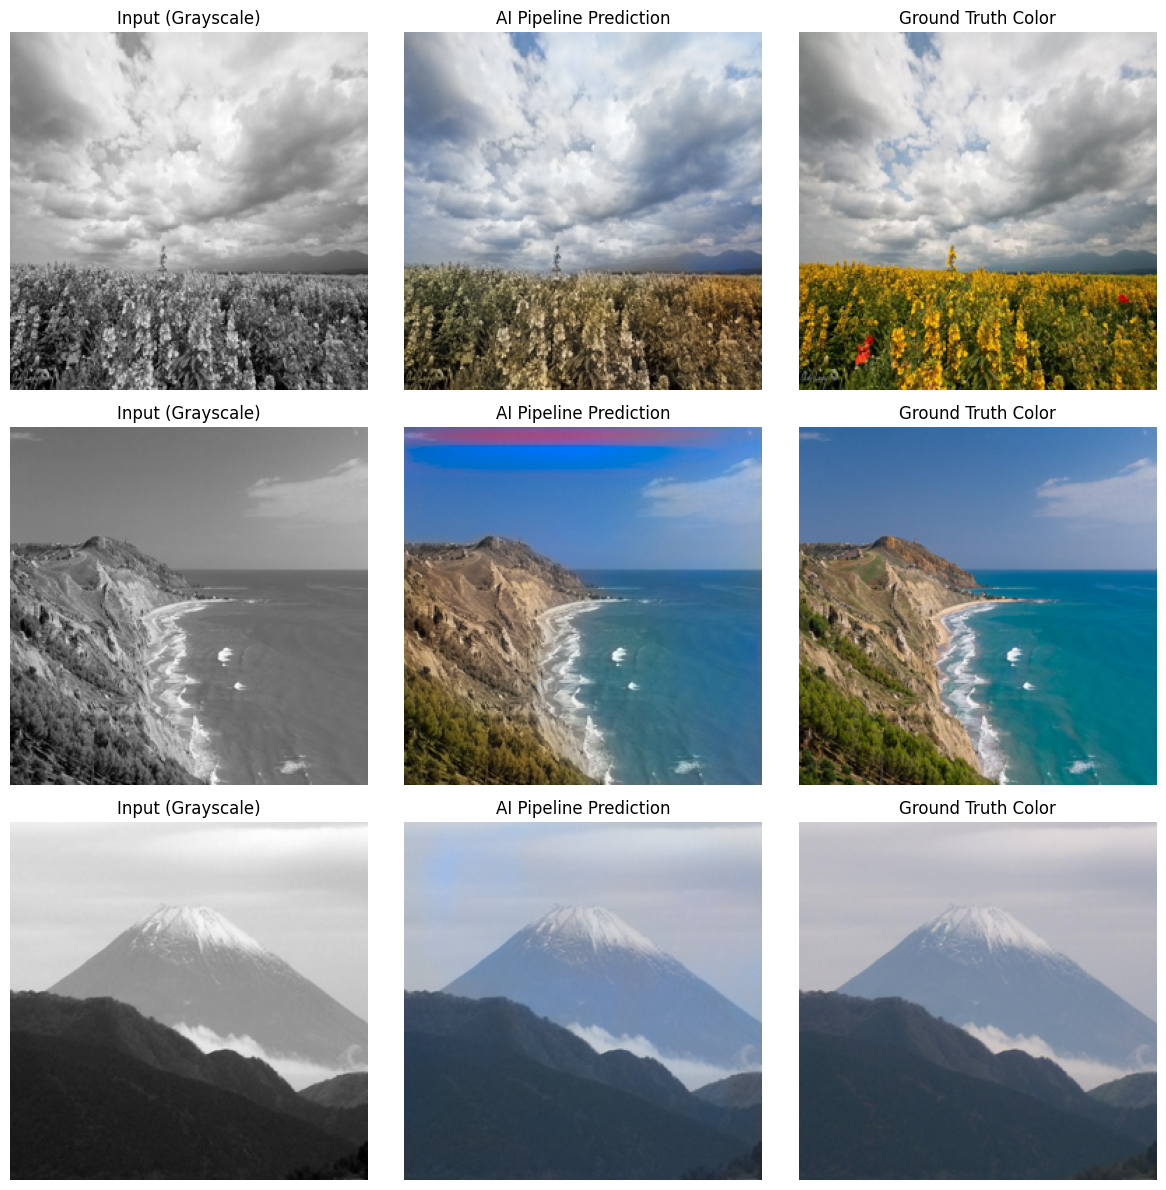

In [6]:
def postprocess_and_reconstruct(L_tensor, ab_tensor):
    """Denormalizes L and ab channels, converts them back to valid RGB spaces."""
    L = L_tensor.squeeze().cpu().numpy() * 100.0
    ab = ab_tensor.squeeze().cpu().numpy() * 255.0 - 128.0
    ab = ab.transpose(1, 2, 0)
    
    lab_reconstructed = np.zeros((IMG_SIZE, IMG_SIZE, 3))
    lab_reconstructed[:, :, 0] = L
    lab_reconstructed[:, :, 1:3] = ab
    
    rgb_converted = lab2rgb(lab_reconstructed)
    return np.clip(rgb_converted, 0, 1)

# Shift model to evaluation space
model.eval()

# Sample a random confirmation batch from validation generators
L_test, ab_test = next(iter(val_loader))
with torch.no_grad():
    inferred_ab = model(L_test.to(device))

# Plot performance validations side-by-side
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    gray_input = L_test[i].squeeze().numpy()
    ai_predicted_rgb = postprocess_and_reconstruct(L_test[i], inferred_ab[i])
    ground_truth_rgb = postprocess_and_reconstruct(L_test[i], ab_test[i])
    
    axes[i, 0].imshow(gray_input, cmap='gray')
    axes[i, 0].set_title("Input (Grayscale)")
    axes[i, 1].imshow(ai_predicted_rgb)
    axes[i, 1].set_title("AI Pipeline Prediction")
    axes[i, 2].imshow(ground_truth_rgb)
    axes[i, 2].set_title("Ground Truth Color")
    
    for ax in axes[i]: 
        ax.axis("off")

plt.tight_layout()
plt.show()

## Sandbox Enviroment

🎉 Model successfully loaded into sandbox environment!


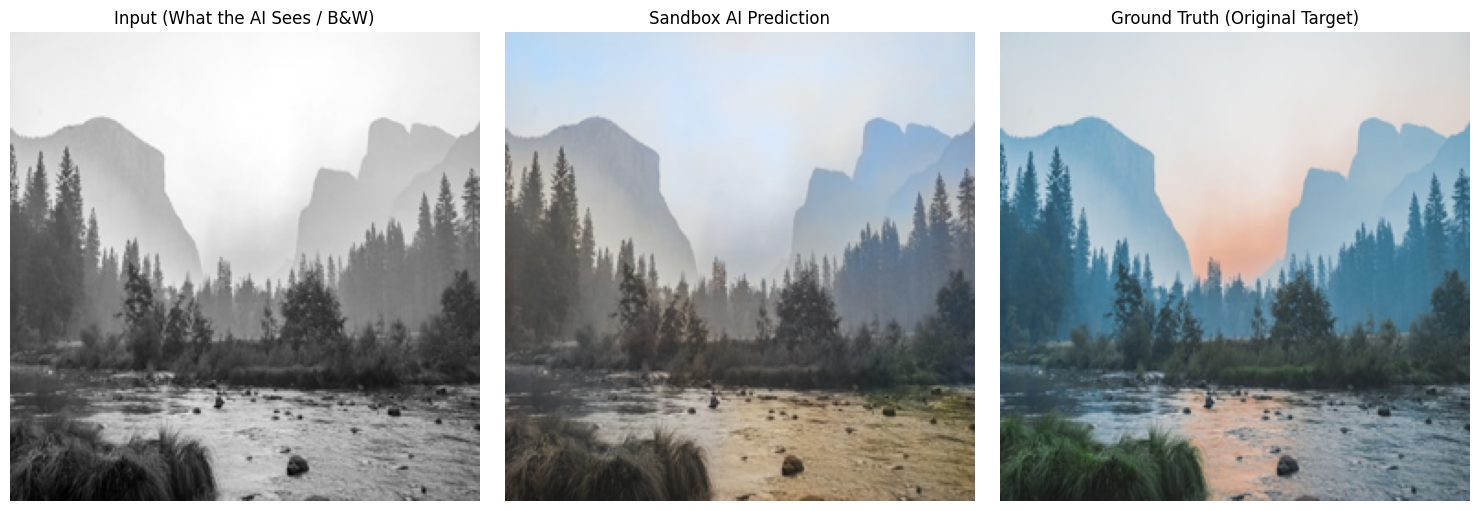

In [9]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import rgb2lab, lab2rgb

import torch
import torch.nn as nn
import torchvision.models as models

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 256

# 2. Re-declare Model Architecture (Required for loading state_dict)
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class ResNetUNetColorizer(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=None) # No need for ImageNet weights since we load our own custom pth
        self.init_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.enc1 = nn.Sequential(resnet.bn1, resnet.relu, resnet.maxpool)
        self.enc2 = resnet.layer1
        self.enc3 = resnet.layer2
        self.enc4 = resnet.layer3
        
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = ConvBlock(256 + 128, 128)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = ConvBlock(128 + 64, 64)
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3 = ConvBlock(64 + 64, 32)
        self.up4 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.final_conv = nn.Sequential(nn.Conv2d(32, 2, kernel_size=1), nn.Sigmoid())

    def forward(self, L):
        x0 = self.init_conv(L)        
        x1 = self.enc1(x0)            
        x2 = self.enc2(x1)            
        x3 = self.enc3(x2)            
        x4 = self.enc4(x3)            
        out = self.up1(x4)
        out = torch.cat([out, x3], dim=1)
        out = self.dec1(out)
        out = self.up2(out)
        out = torch.cat([out, x2], dim=1)
        out = self.dec2(out)
        out = self.up3(out)
        out = torch.cat([out, x0], dim=1)
        out = self.dec3(out)
        out = self.up4(out)
        return self.final_conv(out)

# 3. Load the Saved Model
model_path = "landscape_colorizer_unet.pth"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Could not find '{model_path}'. Ensure you've run the training pipeline cell first!")

model = ResNetUNetColorizer().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("🎉 Model successfully loaded into sandbox environment!")

# 4. Grab a Sample Sandbox Image
# We will download a beautiful test landscape image from Unsplash to try out
sandbox_img_url = "https://images.unsplash.com/photo-1506744038136-46273834b3fb?w=500"
test_image_name = "sandbox_test.jpg"

if not os.path.exists(test_image_name):
    print("Downloading a fresh sandbox testing image...")
    urllib.request.urlretrieve(sandbox_img_url, test_image_name)

# --- USER CONFIGURATION ---
# Replace 'test_image_name' with your own image path (e.g., "my_photo.jpg") if you want to test custom files!
target_image_path = test_image_name 
# --------------------------

# 5. Preprocess Sandbox Image
raw_img = Image.open(target_image_path).convert("RGB")
raw_img = raw_img.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)
img_array = np.array(raw_img)

# Convert to Lab and isolate the Grayscale (L) input channel
lab = rgb2lab(img_array)
lab_normalized = (lab + [0, 128, 128]) / [100, 255, 255]
L_tensor = torch.tensor(lab_normalized[:, :, 0:1].transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device)

# 6. Run AI Inference
with torch.no_grad():
    predicted_ab_tensor = model(L_tensor)

# 7. Post-Process and Reconstruct RGB Result
L_final = L_tensor.squeeze(0).squeeze(0).cpu().numpy() * 100.0
ab_final = predicted_ab_tensor.squeeze(0).cpu().numpy() * 255.0 - 128.0
ab_final = ab_final.transpose(1, 2, 0)

lab_reconstructed = np.zeros((IMG_SIZE, IMG_SIZE, 3))
lab_reconstructed[:, :, 0] = L_final
lab_reconstructed[:, :, 1:3] = ab_final

ai_colorized_rgb = np.clip(lab2rgb(lab_reconstructed), 0, 1)

# 8. Visualize Results Side-by-Side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(L_final, cmap='gray')
axes[0].set_title("Input (What the AI Sees / B&W)")
axes[0].axis("off")

axes[1].imshow(ai_colorized_rgb)
axes[1].set_title("Sandbox AI Prediction")
axes[1].axis("off")

axes[2].imshow(img_array)
axes[2].set_title("Ground Truth (Original Target)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Cell 8: Code (Model Optimization Archival)

In [8]:
# Save model structure weights securely to disk
MODEL_SAVE_PATH = "landscape_colorizer_unet.pth"
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Pipeline weights archived and verified at: '{os.path.abspath(MODEL_SAVE_PATH)}'")

Pipeline weights archived and verified at: '/kaggle/working/landscape_colorizer_unet.pth'
